In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
r2_score,
mean_absolute_error,
mean_squared_error
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/processed/delhi_featured.csv")

print(df.shape)

df.head()

(122745, 36)


,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,aqi_lag3,aqi_lag7,pm25_roll_mean,pm25_roll_std,pm10_roll_mean,pm10_roll_std,season_encoded,aqi_category_encoded,pm_ratio,wind_humidity
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,1.352161,1.352161,1.014612,1.130374,1.035269,1.722115,1.135759,0.734814,-1.226194,-0.999621
1,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,1.352161,0.763291,1.106294,0.190809,1.130946,0.750847,1.135759,0.734814,0.628212,-0.500516
2,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,1.352161,1.352161,1.074515,0.492224,1.153277,0.660327,1.135759,0.734814,-1.560066,-0.605590
3,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,1.352161,1.352161,1.090357,0.386299,1.123750,0.771723,1.135759,0.734814,0.401769,-0.894546
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,1.352161,1.352161,1.008894,0.830975,1.031101,1.254721,1.135759,0.734814,0.452098,-0.658128


In [3]:
features = [

'pm25',
'pm10',
'no2',
'so2',
'co',
'o3',

'temperature',
'humidity',
'wind_speed',
'visibility',

'aqi_lag1',
'aqi_lag3',
'aqi_lag7',

'pm25_roll_mean',
'pm25_roll_std',

'pm10_roll_mean',
'pm10_roll_std',

'season_encoded',

'aqi_category_encoded',

'pm_ratio',

'wind_humidity'

]

X = df[features]


y = df['aqi']

In [4]:
split = int(len(df)*0.8)


X_train = X[:split]

X_test = X[split:]



y_train = y[:split]

y_test = y[split:]

In [5]:
rf = RandomForestRegressor(

n_estimators=100,

max_depth=10,

random_state=42,

n_jobs=-1

)



rf.fit(

X_train,

y_train

)


print("Model Trained")

Model Trained


In [6]:
y_pred = rf.predict(

X_test

)

In [7]:
r2 = r2_score(

y_test,

y_pred

)



mae = mean_absolute_error(

y_test,

y_pred

)



rmse = np.sqrt(

mean_squared_error(

y_test,

y_pred

)

)


print("R² Score :", r2)

print("MAE :", mae)

print("RMSE :", rmse)

R² Score : 0.9999991417917898
MAE : 0.05034006983591996
RMSE : 0.16555689582995564


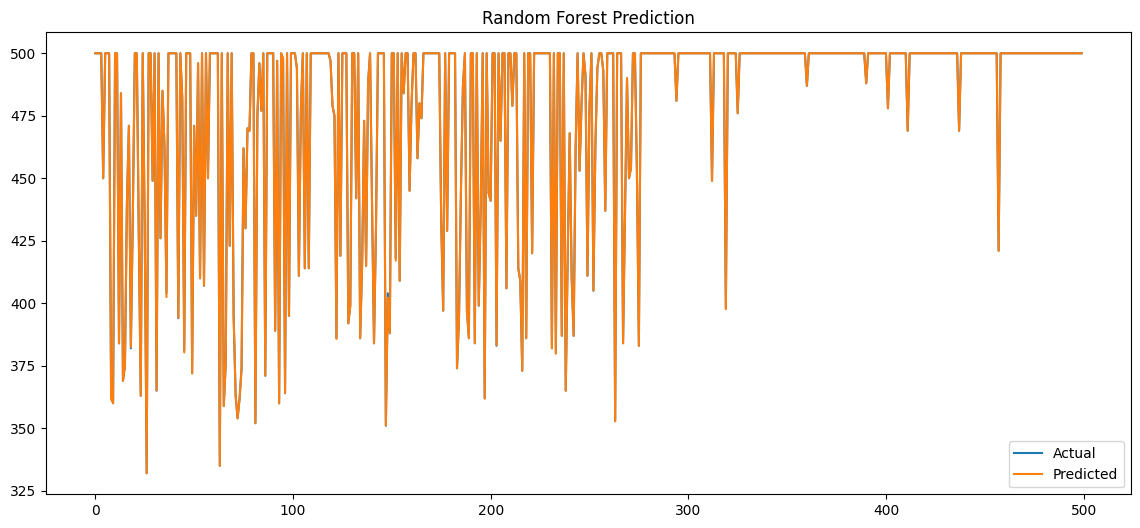

In [8]:
plt.figure(

figsize=(14,6)

)


plt.plot(

y_test.values[:500],

label='Actual'

)



plt.plot(

y_pred[:500],

label='Predicted'

)



plt.legend()


plt.title(

'Random Forest Prediction'

)

plt.show()

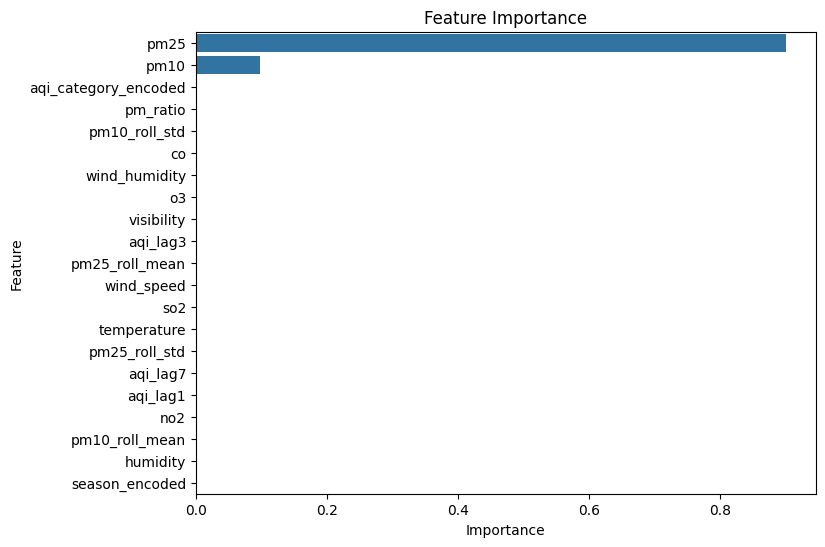

In [10]:
importance = pd.DataFrame({

'Feature':features,

'Importance':rf.feature_importances_

})



importance = importance.sort_values(

'Importance',

ascending=False

)
plt.figure(

figsize=(8,6)

)


sns.barplot(

data=importance,

x='Importance',

y='Feature'

)


plt.title(

"Feature Importance"

)

plt.show()

In [12]:
import joblib


joblib.dump(

rf,

"models/random_forest.pkl"

)


print(

"Model Saved"

)

Model Saved
